<a href="https://www.kaggle.com/code/sonawanelalitsunil/energy-cost-analysis-ml-100?scriptVersionId=273122352" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/residential-and-commercial-energy-cost-dataset/energy_consumption.csv


## Title:
Energy Cost Analysis (Residential & Commercial)

## Description:
This dataset provides comprehensive information on energy costs across residential and commercial sectors. It includes data on electricity and fuel prices, consumption patterns, regional differences, and seasonal variations. The dataset can be used to analyze energy pricing trends, evaluate cost efficiency, and identify factors influencing energy demand in homes and businesses. Ideal for energy economists, data analysts, and sustainability researchers, it supports insights into consumption behavior, cost optimization, and renewable energy planning.

In [2]:
df = pd.read_csv("/kaggle/input/residential-and-commercial-energy-cost-dataset/energy_consumption.csv")

In [3]:
df.head()

,customer_id,customer_type,regions,building_size_m2,occupants,energy_cost_brl
0,CUSTOMER_0001,residential,Northeast,24,2,64.51
1,CUSTOMER_0002,commercial,Midwest,24,1,55.26
2,CUSTOMER_0003,commercial,Southeast,24,1,74.54
3,CUSTOMER_0004,residential,Northeast,45,4,147.06
4,CUSTOMER_0005,residential,Southeast,45,4,143.06


In [4]:
df.tail()

,customer_id,customer_type,regions,building_size_m2,occupants,energy_cost_brl
4995,CUSTOMER_4996,commercial,Southeast,45,4,146.67
4996,CUSTOMER_4997,residential,Southeast,24,1,72.91
4997,CUSTOMER_4998,residential,South,17,2,72.22
4998,CUSTOMER_4999,commercial,Northeast,45,2,86.28
4999,CUSTOMER_5000,residential,Northeast,24,3,57.30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5000 non-null   object 
 1   customer_type     5000 non-null   object 
 2   regions           5000 non-null   object 
 3   building_size_m2  5000 non-null   int64  
 4   occupants         5000 non-null   int64  
 5   energy_cost_brl   5000 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 234.5+ KB


In [6]:
df.describe()

,building_size_m2,occupants,energy_cost_brl
count,5000.00000,5000.000000,5000.000000
mean,39.57620,2.301800,86.874028
std,17.51638,1.032729,24.383261
min,17.00000,1.000000,52.520000
25%,24.00000,1.000000,68.557500
50%,45.00000,2.000000,83.715000
75%,45.00000,3.000000,98.242500
max,77.00000,4.000000,158.610000


In [7]:
df.isnull().sum()

customer_id         0
customer_type       0
regions             0
building_size_m2    0
occupants           0
energy_cost_brl     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.nunique()

customer_id         5000
customer_type          2
regions                5
building_size_m2       5
occupants              4
energy_cost_brl     3641
dtype: int64

In [10]:
df.describe().loc[['mean','max','min']]

,building_size_m2,occupants,energy_cost_brl
mean,39.5762,2.3018,86.874028
max,77.0000,4.0000,158.610000
min,17.0000,1.0000,52.520000


In [11]:
df.shape

(5000, 6)

In [12]:
df.dtypes

customer_id          object
customer_type        object
regions              object
building_size_m2      int64
occupants             int64
energy_cost_brl     float64
dtype: object

In [13]:
df.columns

Index(['customer_id', 'customer_type', 'regions', 'building_size_m2',
       'occupants', 'energy_cost_brl'],
      dtype='object')

## Data visualizations

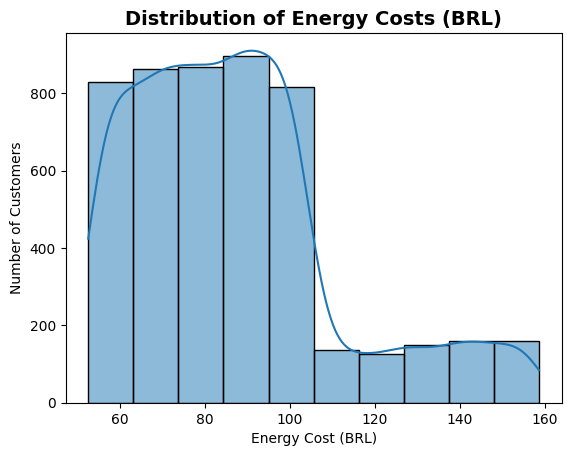

In [14]:
sns.histplot(df['energy_cost_brl'], bins=10, kde=True)
plt.title('Distribution of Energy Costs (BRL)', fontsize=14, fontweight='bold')
plt.xlabel('Energy Cost (BRL)')
plt.ylabel('Number of Customers')
plt.show()

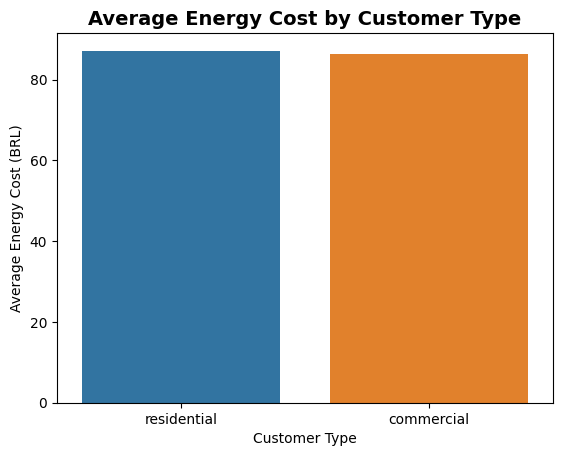

In [15]:
plt.figure()
sns.barplot(x='customer_type', y='energy_cost_brl', data=df, estimator='mean', ci=None)
plt.title('Average Energy Cost by Customer Type', fontsize=14, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Average Energy Cost (BRL)')
plt.show()


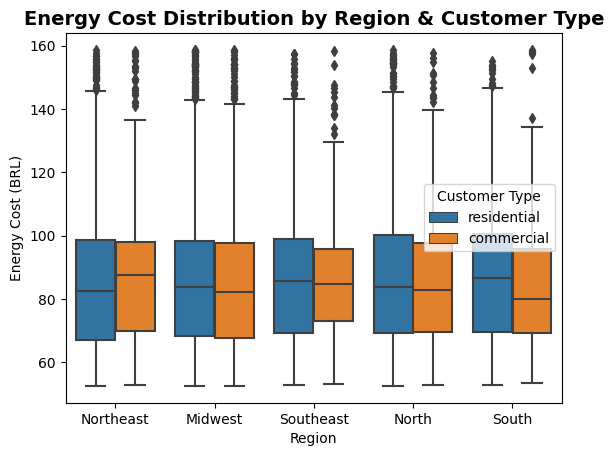

In [16]:
plt.figure()
sns.boxplot(x='regions', y='energy_cost_brl', hue='customer_type', data=df)
plt.title('Energy Cost Distribution by Region & Customer Type', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Energy Cost (BRL)')
plt.legend(title='Customer Type')
plt.show()

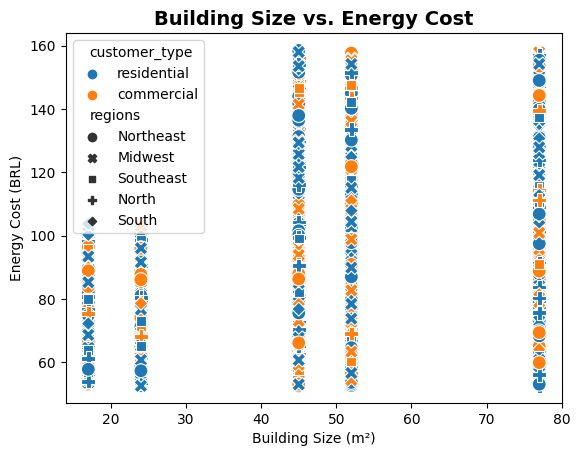

In [17]:
plt.figure()
sns.scatterplot(x='building_size_m2', y='energy_cost_brl', hue='customer_type', style='regions', data=df, s=100)
plt.title('Building Size vs. Energy Cost', fontsize=14, fontweight='bold')
plt.xlabel('Building Size (m²)')
plt.ylabel('Energy Cost (BRL)')
plt.show()

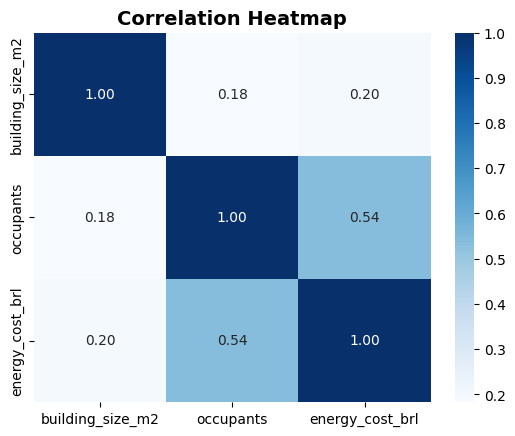

In [18]:
plt.figure()
corr = df[['building_size_m2', 'occupants', 'energy_cost_brl']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

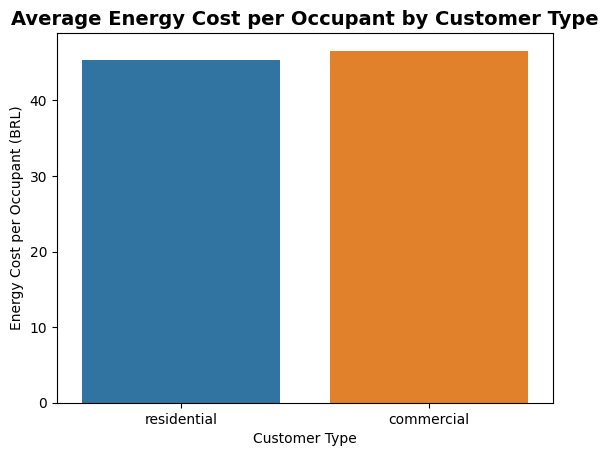

In [19]:
df['cost_per_occupant'] = df['energy_cost_brl'] / df['occupants']
plt.figure()
sns.barplot(x='customer_type', y='cost_per_occupant', data=df, ci=None)
plt.title('Average Energy Cost per Occupant by Customer Type', fontsize=14, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Energy Cost per Occupant (BRL)')
plt.show()

## ML algorithms

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [21]:
df = df.drop(columns=['customer_id'])

# Label encode categorical columns
label_cols = ['customer_type', 'regions']
encoder = LabelEncoder()
for col in label_cols:
    df[col] = encoder.fit_transform(df[col])


In [22]:
X = df.drop(columns=['energy_cost_brl'])
y = df['energy_cost_brl']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred) * 100  # Convert to %
    results[name] = round(score, 2)



In [26]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy (%)'])
print("Model Performance Comparison:\n")
print(results_df.sort_values(by='Accuracy (%)', ascending=False))

Model Performance Comparison:

                      Model  Accuracy (%)
1             Decision Tree        100.00
2             Random Forest        100.00
3         Gradient Boosting         99.94
5             KNN Regressor         96.59
0         Linear Regression         82.13
4  Support Vector Regressor         23.02


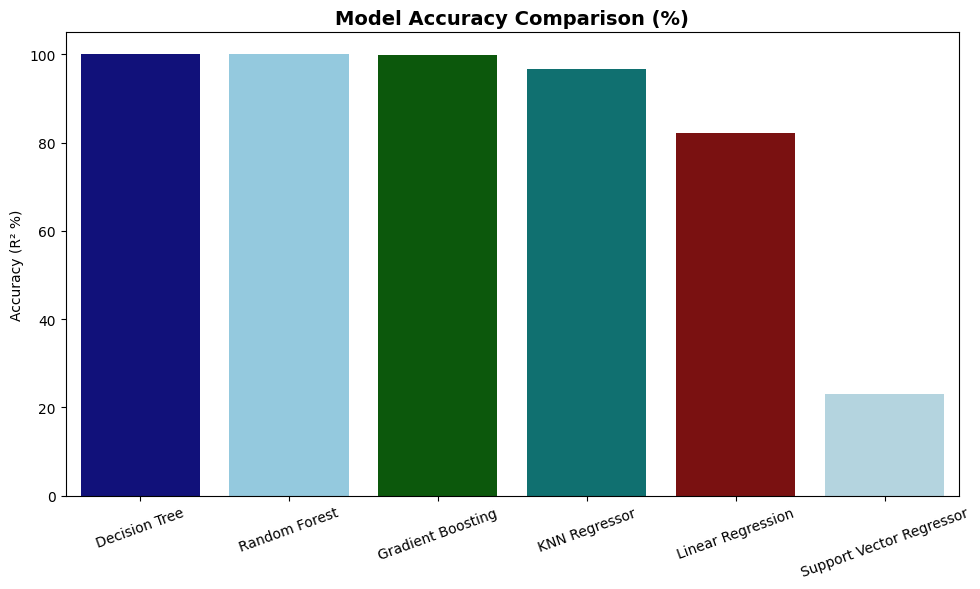

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy (%)', data=results_df.sort_values(by='Accuracy (%)', ascending=False),
            palette=['darkblue', 'skyblue', 'darkgreen', 'teal', 'darkred', 'lightblue'])
plt.title('Model Accuracy Comparison (%)', fontsize=14, fontweight='bold')
plt.xticks(rotation=20)
plt.xlabel('')
plt.ylabel('Accuracy (R² %)')
plt.tight_layout()
plt.show()

## THank you pls upvote!!!!!